In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [29]:

#Load and read the data
df = pd.read_csv("ecommerce_sales_data (2).csv")
#printing the first few rows to understand the data
print(df.head())

   Order Date Product Name     Category Region  Quantity  Sales  Profit
0  2024-12-31      Printer       Office  North         4   3640  348.93
1  2022-11-27        Mouse  Accessories   East         7   1197  106.53
2  2022-05-11       Tablet  Electronics  South         5   5865  502.73
3  2024-03-16        Mouse  Accessories  South         2    786  202.87
4  2022-09-10        Mouse  Accessories   West         1    509  103.28


In [30]:
#Converting the date column to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [31]:
#Grouping the data (time series)
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
print(daily_sales.head())

  Order Date  Sales
0 2022-01-01  24317
1 2022-01-02   7840
2 2022-01-03   2723
3 2022-01-04  18347
4 2022-01-05   9056


In [32]:
#Creating time based features
daily_sales['year'] = daily_sales['Order Date'].dt.year
daily_sales['month'] = daily_sales['Order Date'].dt.month
daily_sales['day'] = daily_sales['Order Date'].dt.day
daily_sales['day_of_week'] = daily_sales['Order Date'].dt.dayofweek

daily_sales.head()

,Order Date,Sales,year,month,day,day_of_week
0,2022-01-01,24317,2022,1,1,5
1,2022-01-02,7840,2022,1,2,6
2,2022-01-03,2723,2022,1,3,0
3,2022-01-04,18347,2022,1,4,1
4,2022-01-05,9056,2022,1,5,2


In [33]:
#Ensure data is sorted in order
daily_sales = daily_sales.sort_values('Order Date')

#creating lag features (past values)
daily_sales['lag_1'] = daily_sales['Sales'].shift(1)
daily_sales['lag_2'] = daily_sales['Sales'].shift(2)
daily_sales['lag_3'] = daily_sales['Sales'].shift(3)

#creating rolling averages (trend)
daily_sales['rolling_7'] = daily_sales['Sales'].rolling(7).mean()
daily_sales['rolling_14'] = daily_sales['Sales'].rolling(14).mean()

In [34]:
#removing rows with missing values created by lag/rolling
daily_sales = daily_sales.dropna().reset_index(drop=True)

In [35]:
#Preparing the data for the model
#Defining the features (x) and the target (y)
X = daily_sales[['year', 'month', 'day', 'day_of_week',
                 'lag_1', 'lag_2', 'lag_3',
                 'rolling_7', 'rolling_14']]

y = daily_sales['Sales']

In [36]:
# Train-test Split
#Use last 30 days for testing
X_train, X_test = X[:-30], X[-30:]
y_train, y_test = y[:-30], y[-30:]

In [37]:

#Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [38]:
#Predict
predictions = model.predict(X_test)

#Evaluate the model performance
mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)

MAE: 5188.030666666667


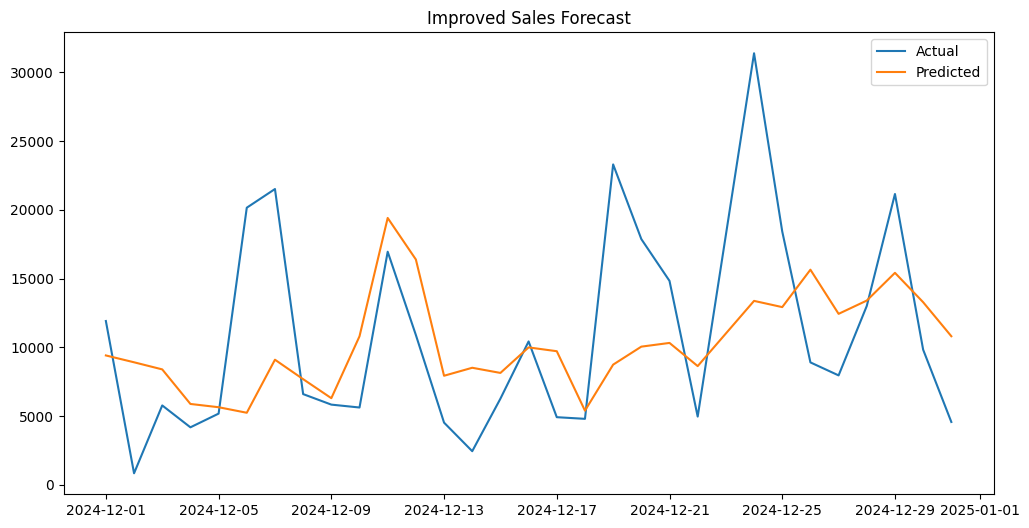

In [39]:

#Plotting the actual sales vs predicted sales
test_dates = daily_sales['Order Date'].iloc[-30:]

plt.figure(figsize=(12,6))
plt.plot(test_dates, y_test.values, label='Actual')
plt.plot(test_dates, predictions, label='Predicted')
plt.legend()
plt.title("Improved Sales Forecast")
plt.show()